### **[Trading for Chart Visualization](https://medium.com/the-visual-analyst/03784121bfc9)**

> *3 trading charts that every trader should know*

In [1]:
!pip install -qq mplfinance

#### **Candlestick Charts**

In [2]:
import sys

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

IN_COLAB = 'google.colab' in sys.modules

import numpy as np
import pandas as pd
import mplfinance as mpf
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['figure.dpi'] = 200

np.random.seed(42)
np.set_printoptions(suppress=True, precision=4)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1500)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.colheader_justify', 'center')

%autosave 10

Autosaving every 10 seconds


,Open,High,Low,Close
Time,,,,
1900-01-01 09:15:00,520.00,522.50,518.00,519.20
1900-01-01 10:00:00,519.20,521.00,517.80,518.50
1900-01-01 11:00:00,518.50,520.00,516.50,517.00
1900-01-01 12:00:00,517.00,518.80,515.50,516.20
1900-01-01 01:00:00,516.20,517.50,514.00,515.00
1900-01-01 02:00:00,515.00,516.00,513.50,514.20
1900-01-01 03:30:00,514.20,515.00,512.80,513.00


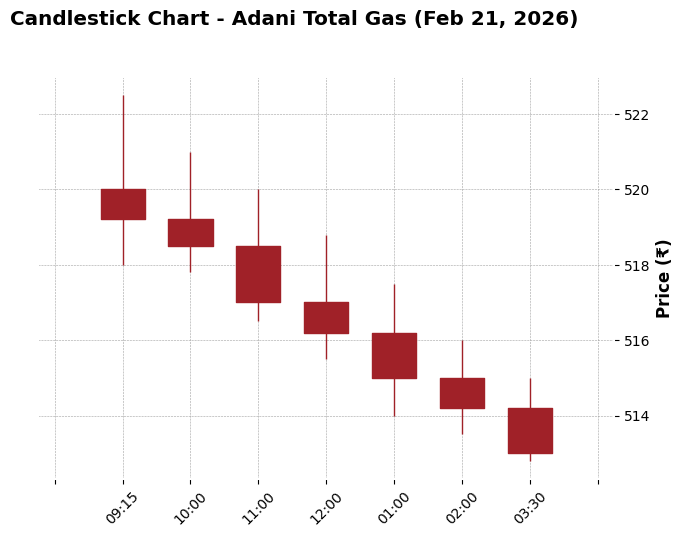

In [3]:
# Sample dataset
data = {
  'Time': ["09:15", "10:00", "11:00", "12:00", "01:00", "02:00", "03:30"],
  'Open': [520.00, 519.20, 518.50, 517.00, 516.20, 515.00, 514.20],
  'High': [522.50, 521.00, 520.00, 518.80, 517.50, 516.00, 515.00],
  'Low':  [518.00, 517.80, 516.50, 515.50, 514.00, 513.50, 512.80],
  'Close':[519.20, 518.50, 517.00, 516.20, 515.00, 514.20, 513.00]
}

df = pd.DataFrame(data)
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M')
df.set_index('Time', inplace=True)
display(df)

# Plot Candlestick Chart
mpf.plot(df, type='candle', style='charles',
         title='Candlestick Chart - Adani Total Gas (Feb 21, 2026)',
         ylabel='Price (₹)', volume=False)

#### **Renko Charts**

In [4]:
data = {
  'Time': ["09:15", "10:00", "11:00", "12:00", "01:00", "02:00", "03:30"],
  'Close':[519.20, 518.50, 517.00, 516.20, 515.00, 514.20, 513.00]
}

df = pd.DataFrame(data)
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M')

display(df)

,Time,Close
0,1900-01-01 09:15:00,519.20
1,1900-01-01 10:00:00,518.50
2,1900-01-01 11:00:00,517.00
3,1900-01-01 12:00:00,516.20
4,1900-01-01 01:00:00,515.00
5,1900-01-01 02:00:00,514.20
6,1900-01-01 03:30:00,513.00


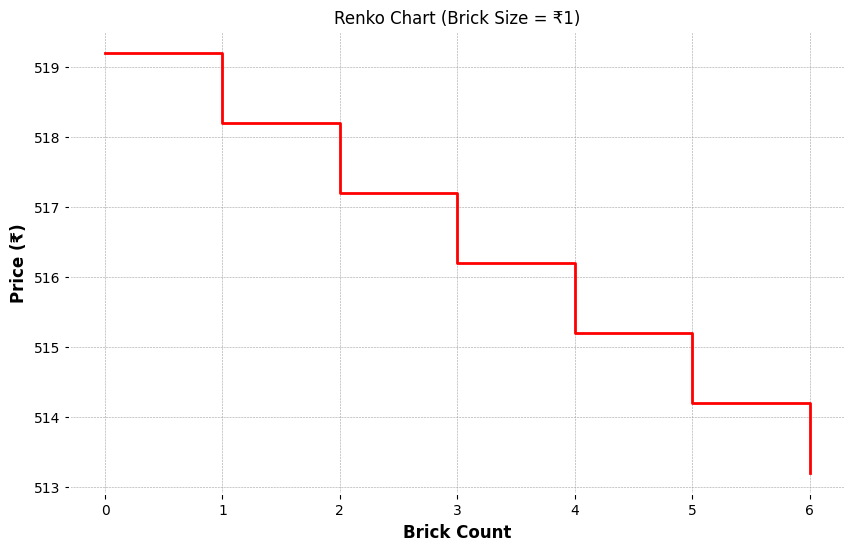

In [5]:
class Renko:
  def __init__(self, brick_size):
    self.brick_size = brick_size
    self.bricks = []

  def build(self, prices):
    for price in prices:
      if not self.bricks:
        self.bricks.append(price)
      else:
        diff = price - self.bricks[-1]
        if abs(diff) >= self.brick_size:
          steps = int(diff / self.brick_size)
          for _ in range(abs(steps)):
            self.bricks.append(self.bricks[-1] + self.brick_size * (1 if steps > 0 else -1))

renko = Renko(brick_size=1)
renko.build(df['Close'].tolist())

# Plot Renko Chart
plt.figure(figsize=(10,6))
plt.plot(range(len(renko.bricks)), renko.bricks, drawstyle='steps-post', color='red')
plt.title("Renko Chart (Brick Size = ₹1)")
plt.xlabel("Brick Count")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

#### **Line Charts**

,Time,Close
0,1900-01-01 09:15:00,519.20
1,1900-01-01 10:00:00,518.50
2,1900-01-01 11:00:00,517.00
3,1900-01-01 12:00:00,516.20
4,1900-01-01 01:00:00,515.00
5,1900-01-01 02:00:00,514.20
6,1900-01-01 03:30:00,513.00


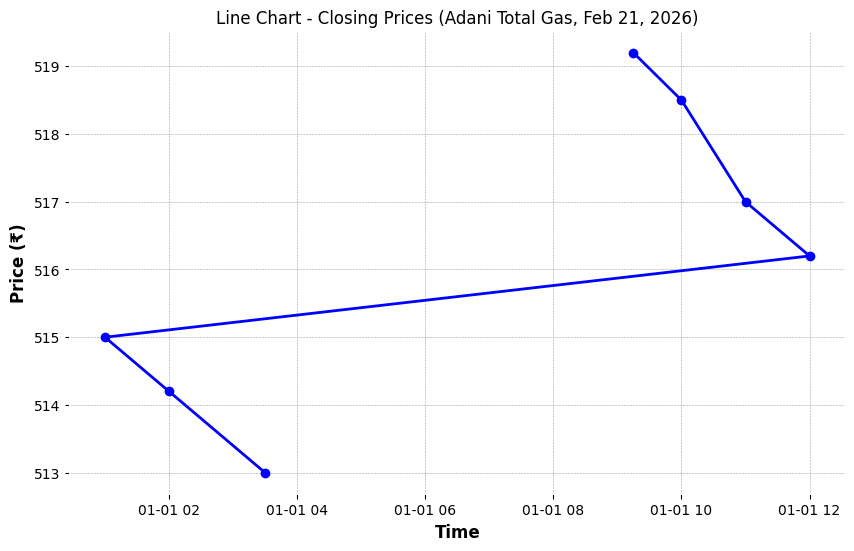

In [6]:
# Sample dataset
data = {
  'Time': ["09:15", "10:00", "11:00", "12:00", "01:00", "02:00", "03:30"],
  'Close':[519.20, 518.50, 517.00, 516.20, 515.00, 514.20, 513.00]
}

df = pd.DataFrame(data)
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M')

display(df)

plt.figure(figsize=(10,6))
plt.plot(df['Time'], df['Close'], marker='o', color='blue', linewidth=2)
plt.title("Line Chart - Closing Prices (Adani Total Gas, Feb 21, 2026)")
plt.xlabel("Time")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()